# Electricity Consumption Forecasting
Bohdan Pavlyshenko (https://www.linkedin.com/in/bpavlyshenko) 

**Dataset:** [UCI ML Repository — Tetouan City Power Consumption (ID 849)](https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city)

---

## Overview

This notebook forecasts electricity consumption across three distribution zones in Tetouan, Morocco.
The dataset contains **52,416 observations** at 10-minute intervals from January–December 2017,
along with weather covariates (temperature, humidity, wind speed, diffuse solar flows).

**Notebook structure:**

| Section | Content |
|---------|---------|
| EDA | Temporal patterns, correlations, seasonality |
| Lasso Regression | Baseline linear model with cyclical time features and lag features |
| Neural Forecasting | Deep learning models: N-BEATSx, N-HiTS, LSTM, TFT |

**Requirements:** `ucimlrepo`, `neuralforecast` (installed separately from standard ML stack)


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")


Libraries loaded.


## 1. Data Loading

We fetch the dataset directly from the UCI ML Repository using the `ucimlrepo` package.
The dataset ID 849 corresponds to the Tetouan City Power Consumption dataset.


In [2]:
ds = fetch_ucirepo(id=849)

X = ds.data.features.copy()
y = ds.data.targets.copy()

df = pd.concat([X, y], axis=1)

# Normalise column names
df.columns = (
    pd.Index(df.columns)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values("DateTime").reset_index(drop=True)

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print("Date range:", df.DateTime.min(), "to", df.DateTime.max())


Columns: ['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption', 'Zone 2 Power Consumption', 'Zone 3 Power Consumption']
Shape: (52416, 9)
Date range: 2017-01-01 00:00:00 to 2017-12-30 23:50:00


In [3]:
df.head()


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


## 2. Basic Feature Engineering

Calendar features (hour, day of week, month) capture recurring temporal patterns
that are essential for electricity demand forecasting.


In [4]:
df["date"]       = df["DateTime"].dt.date
df["hour"]       = df["DateTime"].dt.hour
df["dayofweek"]  = df["DateTime"].dt.dayofweek
df["day_name"]   = df["DateTime"].dt.day_name()
df["dayofmonth"] = df["DateTime"].dt.day
df["month"]      = df["DateTime"].dt.month
df["month_name"] = df["DateTime"].dt.month_name()

zone_cols = [
    "Zone 1 Power Consumption",
    "Zone 2 Power Consumption",
    "Zone 3 Power Consumption",
]

covariate_cols = [
    "Temperature",
    "Humidity",
    "Wind Speed",
    "general diffuse flows",
    "diffuse flows",
]

print("Zone columns    :", zone_cols)
print("Covariate columns:", covariate_cols)


Zone columns    : ['Zone 1 Power Consumption', 'Zone 2 Power Consumption', 'Zone 3 Power Consumption']
Covariate columns: ['Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows']


## 3. Exploratory Data Analysis

### 3.1 Data Quality


In [5]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Descriptive statistics:")
display(df[zone_cols + covariate_cols].describe().T)


Missing values per column:
DateTime                    0
Temperature                 0
Humidity                    0
Wind Speed                  0
general diffuse flows       0
diffuse flows               0
Zone 1 Power Consumption    0
Zone 2 Power Consumption    0
Zone 3 Power Consumption    0
date                        0
hour                        0
dayofweek                   0
day_name                    0
dayofmonth                  0
month                       0
month_name                  0
dtype: int64

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Zone 1 Power Consumption,52416.0,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512
Zone 2 Power Consumption,52416.0,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076
Zone 3 Power Consumption,52416.0,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636
Temperature,52416.0,18.810024,5.815476,3.247000,14.410000,18.780000,22.890000,40.01000
Humidity,52416.0,68.259518,15.551177,11.340000,58.310000,69.860000,81.400000,94.80000
Wind Speed,52416.0,1.959489,2.348862,0.050000,0.078000,0.086000,4.915000,6.48300
general diffuse flows,52416.0,182.696614,264.400960,0.004000,0.062000,5.035500,319.600000,1163.00000
diffuse flows,52416.0,75.028022,124.210949,0.011000,0.122000,4.456000,101.000000,936.00000


### 3.2 Correlation Heatmap


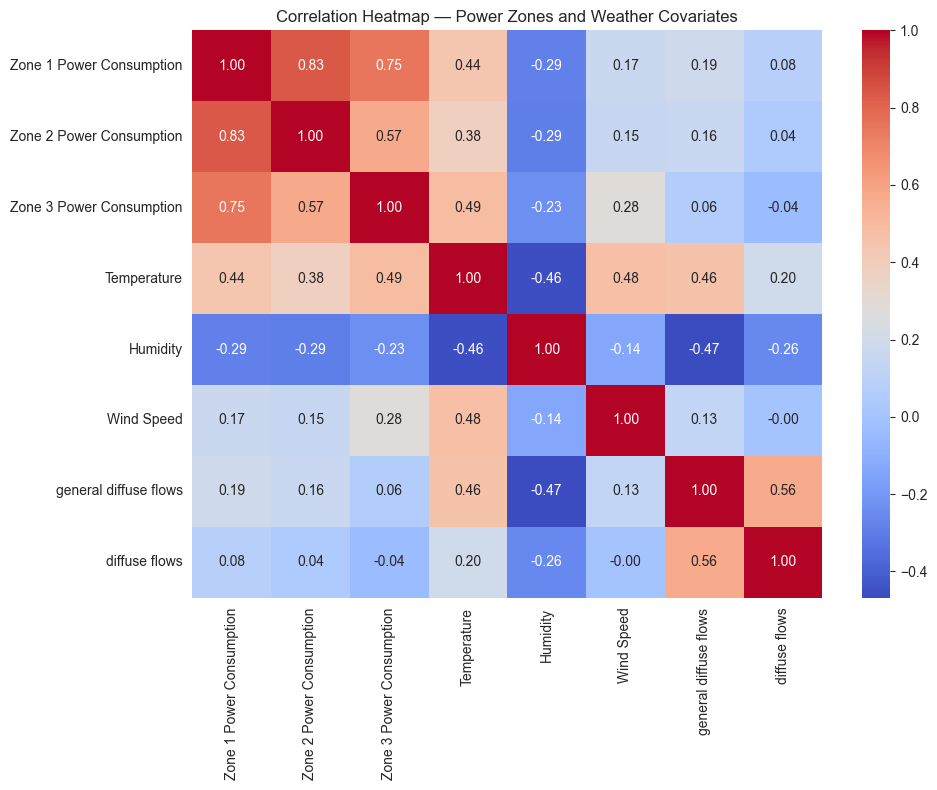

In [6]:
plt.figure(figsize=(10, 8))
corr = df[zone_cols + covariate_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Power Zones and Weather Covariates")
plt.tight_layout()
plt.show()


### 3.3 Time-Series Overview


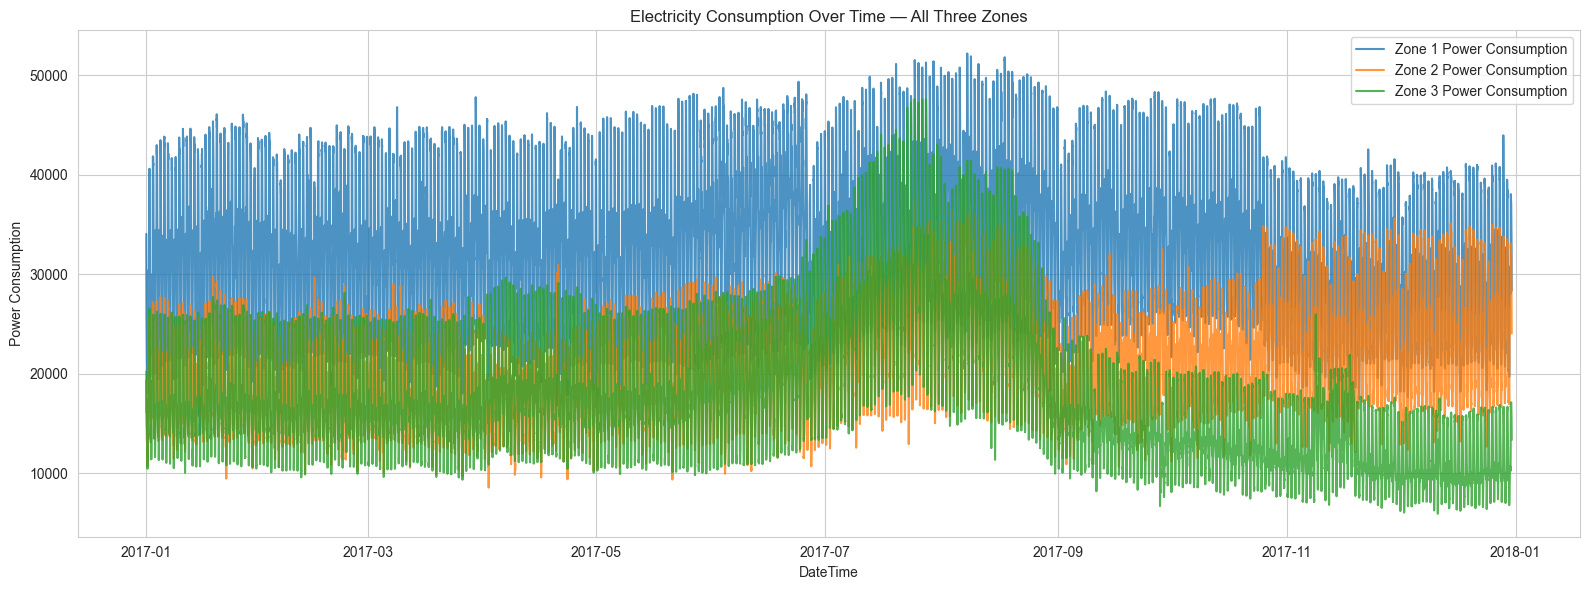

In [7]:
plt.figure(figsize=(16, 6))
for col in zone_cols:
    plt.plot(df["DateTime"], df[col], label=col, alpha=0.8)
plt.title("Electricity Consumption Over Time — All Three Zones")
plt.xlabel("DateTime")
plt.ylabel("Power Consumption")
plt.legend()
plt.tight_layout()
plt.show()


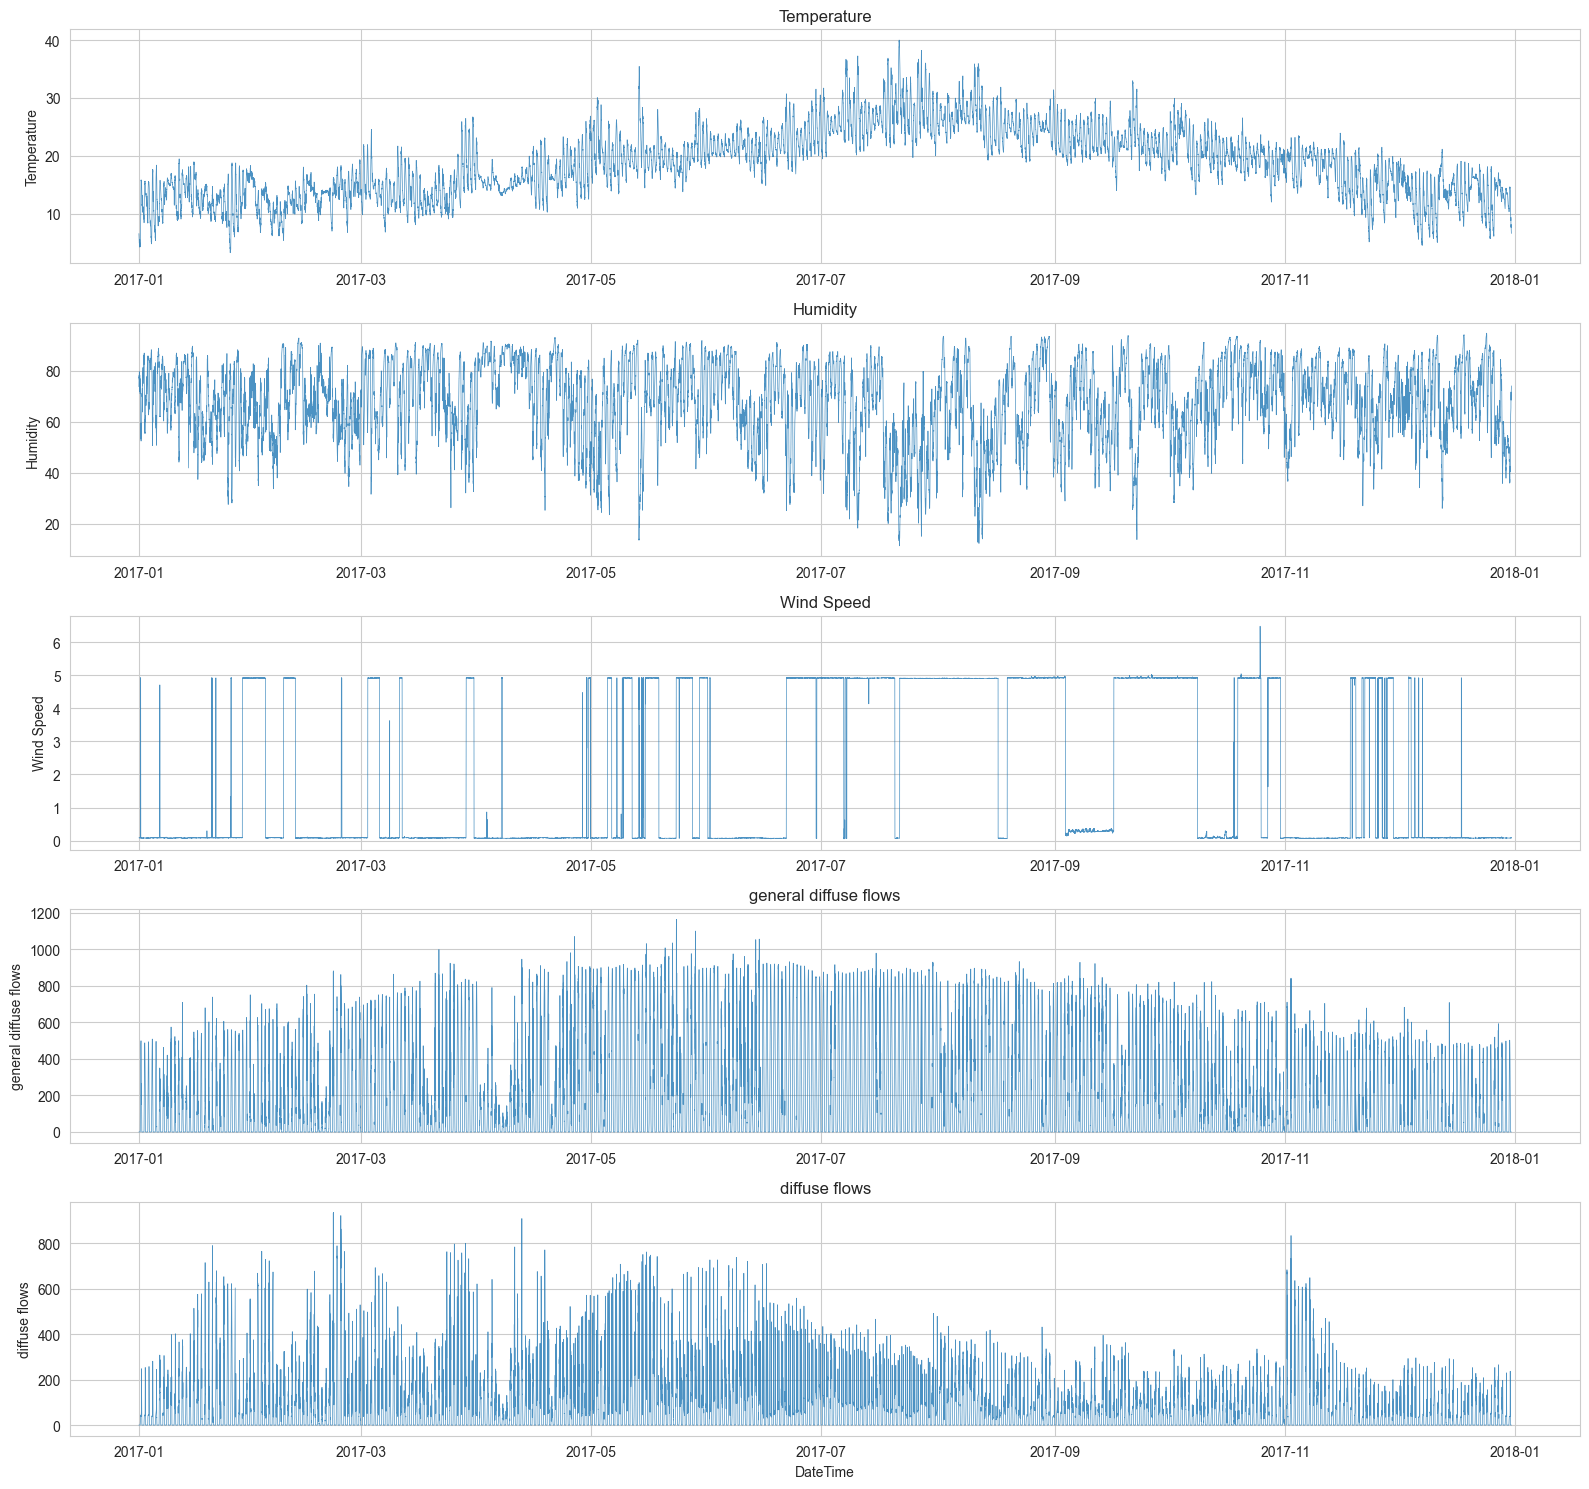

In [8]:
# Weather covariate overview
fig, axes = plt.subplots(len(covariate_cols), 1, figsize=(16, 3 * len(covariate_cols)))
for ax, col in zip(axes, covariate_cols):
    ax.plot(df["DateTime"], df[col], linewidth=0.5, alpha=0.8)
    ax.set_title(col)
    ax.set_ylabel(col)
axes[-1].set_xlabel("DateTime")
plt.tight_layout()
plt.show()


### 3.4 Reshape to Long Format

A long-format DataFrame makes it easier to compare all three zones using Seaborn's
`hue` parameter.


In [9]:
long_df = df.melt(
    id_vars=[
        "DateTime", "date", "hour", "dayofweek", "day_name",
        "dayofmonth", "month", "month_name",
        "Temperature", "Humidity", "Wind Speed",
        "general diffuse flows", "diffuse flows",
    ],
    value_vars=zone_cols,
    var_name="zone",
    value_name="consumption",
)

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
print("Long dataframe shape:", long_df.shape)
long_df.head()


Long dataframe shape: (157248, 15)


,DateTime,date,hour,dayofweek,day_name,dayofmonth,month,month_name,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,zone,consumption
0,2017-01-01 00:00:00,2017-01-01,0,6,Sunday,1,1,January,6.559,73.8,0.083,0.051,0.119,Zone 1 Power Consumption,34055.69620
1,2017-01-01 00:10:00,2017-01-01,0,6,Sunday,1,1,January,6.414,74.5,0.083,0.070,0.085,Zone 1 Power Consumption,29814.68354
2,2017-01-01 00:20:00,2017-01-01,0,6,Sunday,1,1,January,6.313,74.5,0.080,0.062,0.100,Zone 1 Power Consumption,29128.10127
3,2017-01-01 00:30:00,2017-01-01,0,6,Sunday,1,1,January,6.121,75.0,0.083,0.091,0.096,Zone 1 Power Consumption,28228.86076
4,2017-01-01 00:40:00,2017-01-01,0,6,Sunday,1,1,January,5.921,75.7,0.081,0.048,0.085,Zone 1 Power Consumption,27335.69620


### 3.5 Daily and Hourly Patterns


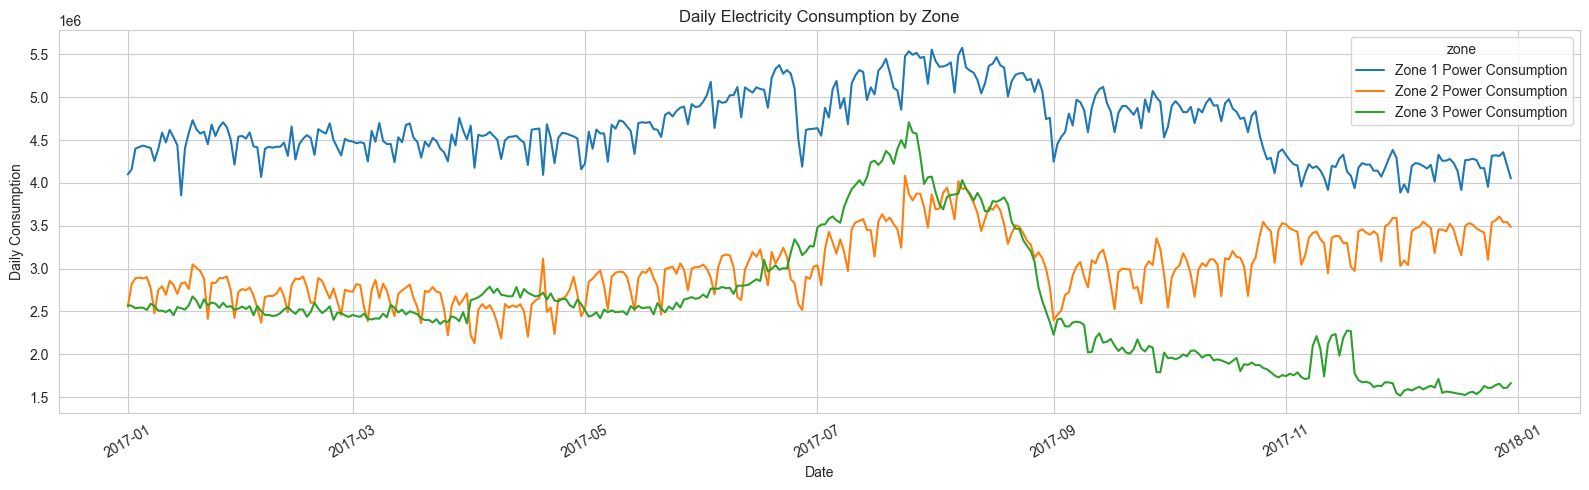

In [10]:
daily_df = (
    long_df.groupby(["date", "zone"], as_index=False)["consumption"].sum()
)

plt.figure(figsize=(16, 5))
sns.lineplot(data=daily_df, x="date", y="consumption", hue="zone")
plt.title("Daily Electricity Consumption by Zone")
plt.xlabel("Date")
plt.ylabel("Daily Consumption")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


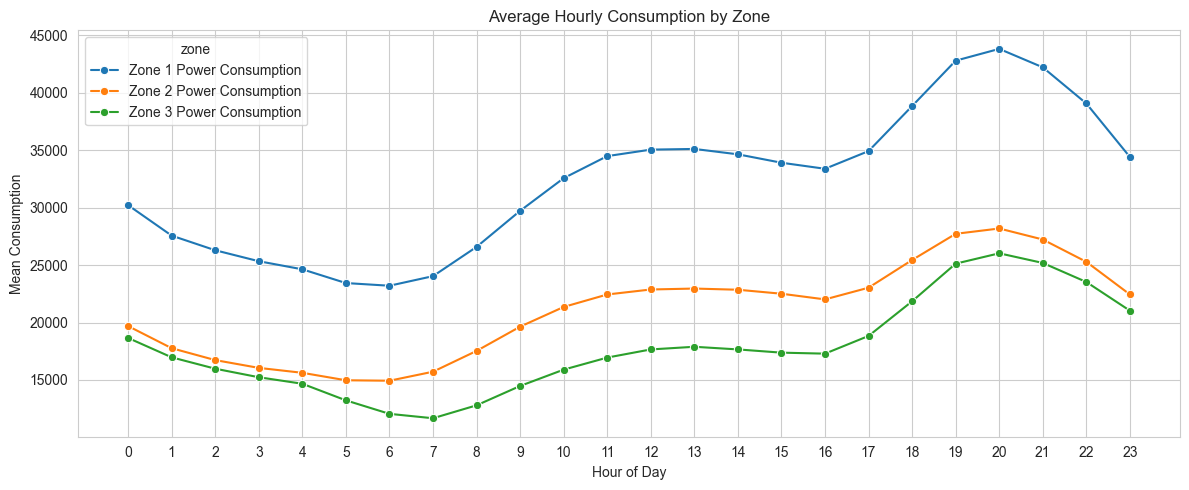

In [11]:
hourly_df = long_df.groupby(["hour", "zone"], as_index=False)["consumption"].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_df, x="hour", y="consumption", hue="zone", marker="o")
plt.title("Average Hourly Consumption by Zone")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Consumption")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


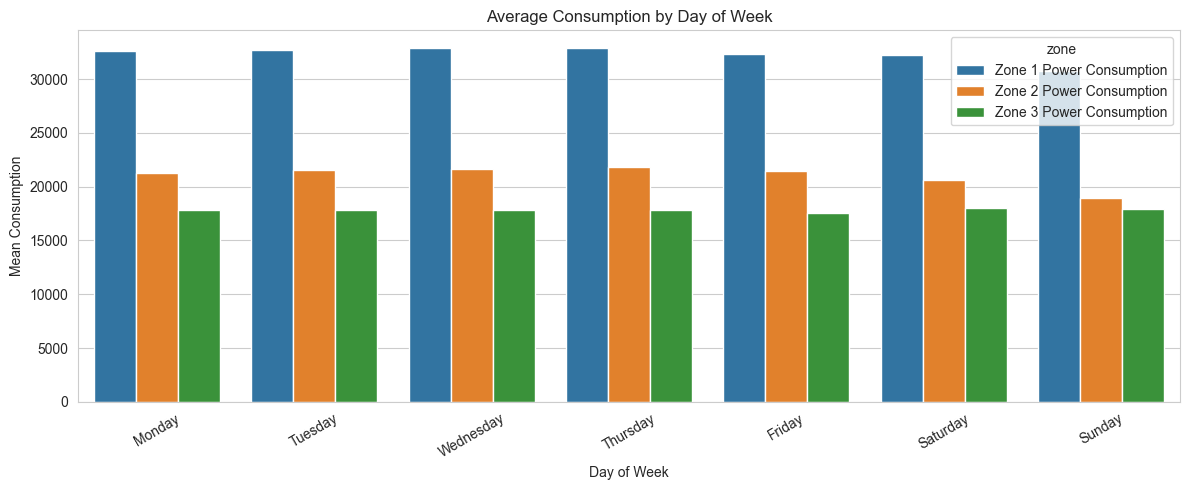

In [12]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_df = long_df.groupby(["day_name", "zone"], as_index=False)["consumption"].mean()
dow_df["day_name"] = pd.Categorical(dow_df["day_name"], categories=dow_order, ordered=True)
dow_df = dow_df.sort_values("day_name")

plt.figure(figsize=(12, 5))
sns.barplot(data=dow_df, x="day_name", y="consumption", hue="zone")
plt.title("Average Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Mean Consumption")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 3.6 Boxplots by Hour and Day of Week


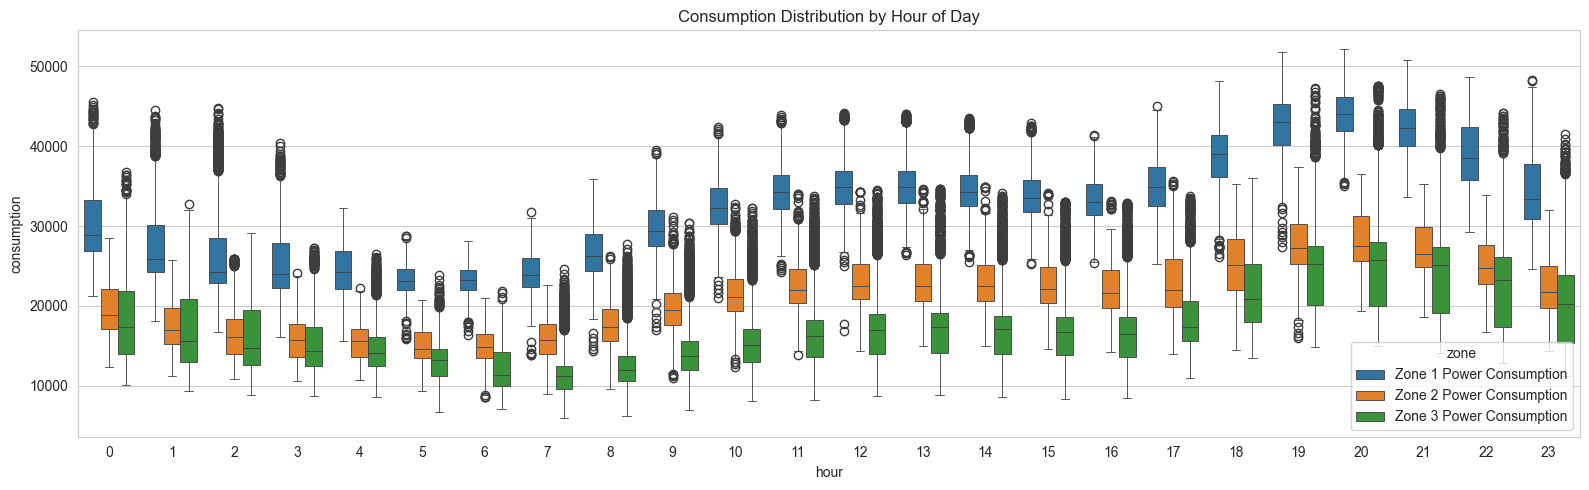

In [13]:
plt.figure(figsize=(16, 5))
sns.boxplot(data=long_df, x="hour", y="consumption", hue="zone", linewidth=0.6)
plt.title("Consumption Distribution by Hour of Day")
plt.tight_layout()
plt.show()


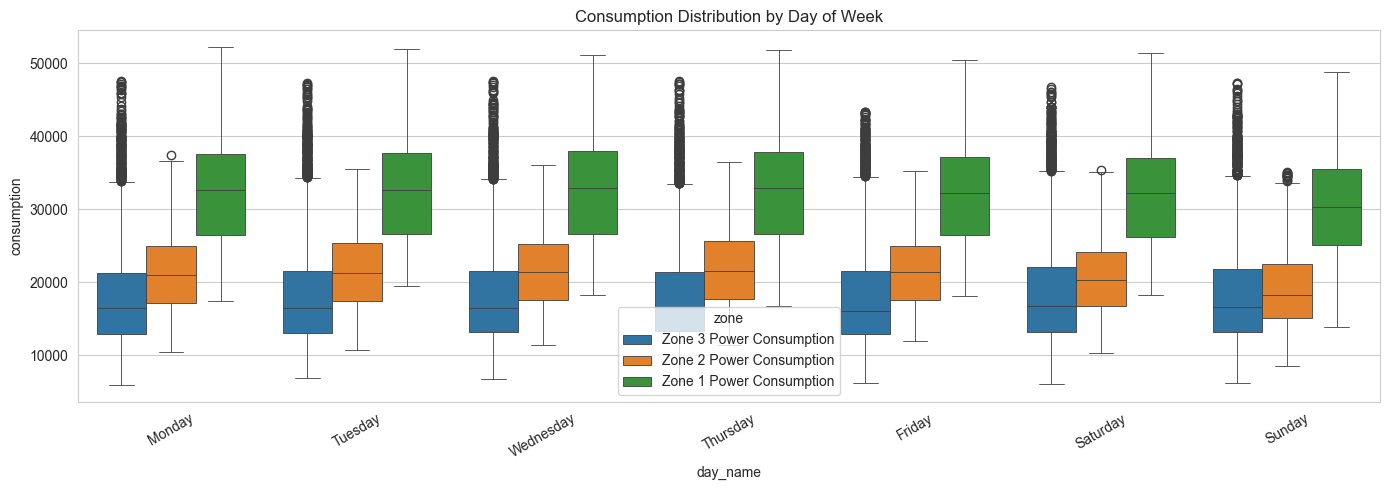

In [14]:
plot_df = long_df.copy()
plot_df["day_name"] = pd.Categorical(plot_df["day_name"], categories=dow_order, ordered=True)
plot_df = plot_df.sort_values("day_name")

plt.figure(figsize=(14, 5))
sns.boxplot(data=plot_df, x="day_name", y="consumption", hue="zone", linewidth=0.6)
plt.title("Consumption Distribution by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 4. Lasso Regression Baseline

### 4.1 Overview

Lasso regression serves as an interpretable baseline for the forecasting task. We include:
- **Weather covariates** as exogenous features
- **Cyclical time encodings** (sine/cosine) to capture periodicity without imposing ordinality
- **Lag features** for Zone 1 to capture autocorrelation in demand

**Split strategy:** Chronological 80/20 split — the last 20% of the time series forms the
validation set. This prevents data leakage from future to past.


In [15]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------------------------
# Feature engineering
# -----------------------------------------------
df2 = df.copy()

df2["hour_sin"]  = np.sin(2 * np.pi * df2["hour"] / 24.0)
df2["hour_cos"]  = np.cos(2 * np.pi * df2["hour"] / 24.0)
df2["dow_sin"]   = np.sin(2 * np.pi * df2["dayofweek"] / 7.0)
df2["dow_cos"]   = np.cos(2 * np.pi * df2["dayofweek"] / 7.0)
df2["month_sin"] = np.sin(2 * np.pi * df2["month"] / 12.0)
df2["month_cos"] = np.cos(2 * np.pi * df2["month"] / 12.0)

# Autoregressive lag features for Zone 1
df2["lag_1"]   = df2["Zone 1 Power Consumption"].shift(1)
df2["lag_6"]   = df2["Zone 1 Power Consumption"].shift(6)    # 1 hour ago (10-min data)
df2["lag_144"] = df2["Zone 1 Power Consumption"].shift(144)  # 24 hours ago

df2 = df2.dropna().reset_index(drop=True)

target_col = "Zone 1 Power Consumption"
feature_cols = [
    "Temperature", "Humidity", "Wind Speed",
    "general diffuse flows", "diffuse flows",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
    "lag_1", "lag_6", "lag_144",
]

Xf = df2[feature_cols].copy()
yf = df2[target_col].copy()

n = len(df2)
train_end = int(n * 0.8)

Xf_train = Xf.iloc[:train_end]
yf_train = yf.iloc[:train_end]
Xf_val   = Xf.iloc[train_end:]
yf_val   = yf.iloc[train_end:]
dt_train = df2["DateTime"].iloc[:train_end]
dt_val   = df2["DateTime"].iloc[train_end:]

print(f"Train: {Xf_train.shape} | Validation: {Xf_val.shape}")


Train: (41817, 14) | Validation: (10455, 14)


In [16]:
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso",  Lasso(alpha=0.1, max_iter=20000, random_state=RANDOM_STATE)),
])
lasso_pipe.fit(Xf_train, yf_train)

train_pred = lasso_pipe.predict(Xf_train)
val_pred   = lasso_pipe.predict(Xf_val)


def print_metrics(label, y_true, y_pred):
    """Print MAE, MSE, RMSE, and R-squared for a set of predictions.

    Args:
        label (str): Section label for display.
        y_true (array-like): Ground-truth values.
        y_pred (array-like): Predicted values.
    """
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"{label}")
    print(f"  MAE  = {mae:.3f}")
    print(f"  MSE  = {mse:.3f}")
    print(f"  RMSE = {rmse:.3f}")
    print(f"  R2   = {r2:.3f}")


print_metrics("Train", yf_train, train_pred)
print_metrics("Validation", yf_val, val_pred)


Train
  MAE  = 306.380
  MSE  = 236999.740
  RMSE = 486.826
  R2   = 0.995
Validation
  MAE  = 271.660
  MSE  = 177579.511
  RMSE = 421.402
  R2   = 0.995


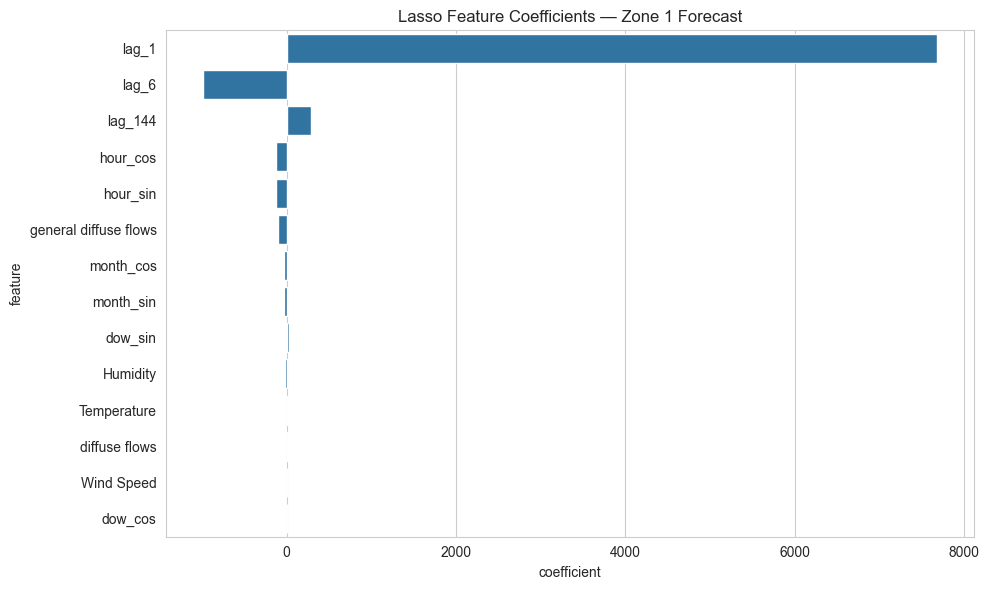

In [17]:
# Lasso feature coefficients
lasso_model = lasso_pipe.named_steps["lasso"]
coef_df = pd.DataFrame({
    "feature":     feature_cols,
    "coefficient": lasso_model.coef_,
}).sort_values("coefficient", key=np.abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x="coefficient", y="feature")
plt.title("Lasso Feature Coefficients — Zone 1 Forecast")
plt.tight_layout()
plt.show()


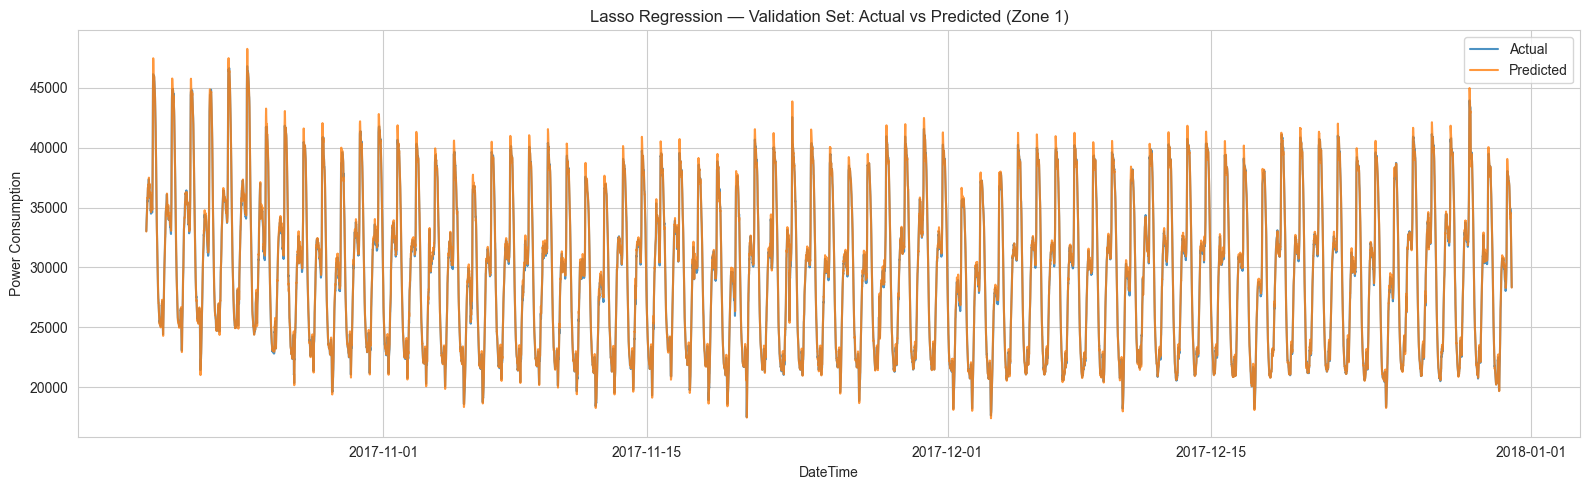

In [18]:
# Actual vs predicted — full validation set
plt.figure(figsize=(16, 5))
plt.plot(dt_val.values, yf_val.values, label="Actual",    alpha=0.8)
plt.plot(dt_val.values, val_pred,      label="Predicted", alpha=0.8)
plt.title("Lasso Regression — Validation Set: Actual vs Predicted (Zone 1)")
plt.xlabel("DateTime")
plt.ylabel("Power Consumption")
plt.legend()
plt.tight_layout()
plt.show()


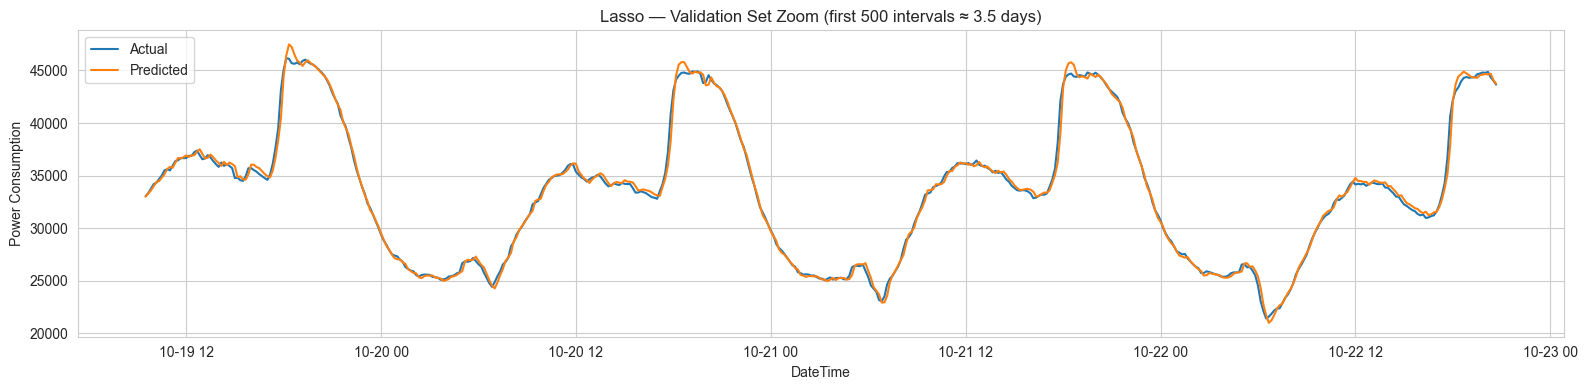

In [19]:
# Zoomed 500-step view for clarity
zoom_n = 500
plt.figure(figsize=(16, 4))
plt.plot(dt_val.iloc[:zoom_n].values, yf_val.iloc[:zoom_n].values, label="Actual")
plt.plot(dt_val.iloc[:zoom_n].values, val_pred[:zoom_n],           label="Predicted")
plt.title(f"Lasso — Validation Set Zoom (first {zoom_n} intervals ≈ 3.5 days)")
plt.xlabel("DateTime")
plt.ylabel("Power Consumption")
plt.legend()
plt.tight_layout()
plt.show()


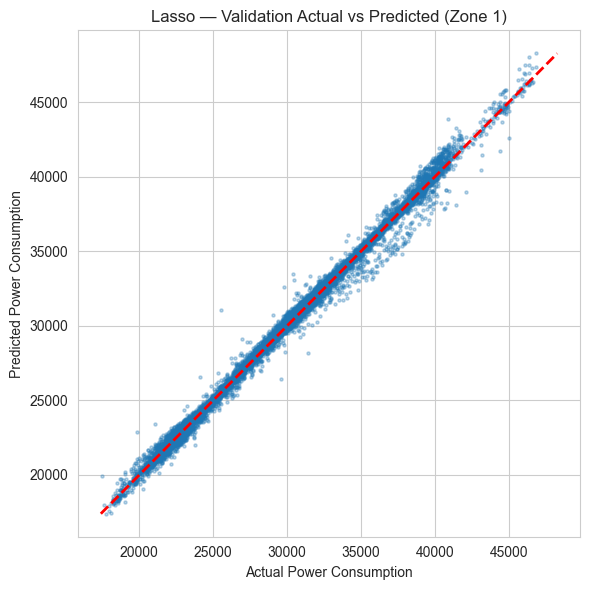

In [20]:
# Scatter: actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(yf_val, val_pred, alpha=0.3, s=5)
lims = [min(yf_val.min(), val_pred.min()), max(yf_val.max(), val_pred.max())]
plt.plot(lims, lims, "r--", linewidth=2)
plt.xlabel("Actual Power Consumption")
plt.ylabel("Predicted Power Consumption")
plt.title("Lasso — Validation Actual vs Predicted (Zone 1)")
plt.tight_layout()
plt.show()


## 5. Neural Forecasting with NeuralForecast

### 5.1 Overview

We use the `neuralforecast` library to train four state-of-the-art deep learning
forecasting models on all three zones simultaneously:

| Model | Architecture | Key Strength |
|-------|-------------|--------------|
| **N-BEATSx** | Basis Expansion Network + exogenous | Interpretable, strong univariate |
| **N-HiTS** | Hierarchical interpolation | Multi-scale temporal patterns |
| **LSTM** | Long Short-Term Memory | Sequential modelling |
| **TFT** | Temporal Fusion Transformer | Interpretable attention + gating |

**Forecast horizon:** 24 steps (4 hours) at 10-minute resolution.


In [21]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx, NHITS, TFT, LSTM

# Reload clean dataset
ds2 = fetch_ucirepo(id=849)
X2  = ds2.data.features.copy()
y2  = ds2.data.targets.copy()

df3 = pd.concat([X2, y2], axis=1)
df3.columns = (
    pd.Index(df3.columns).str.strip().str.replace(r"\s+", " ", regex=True)
)
df3["DateTime"] = pd.to_datetime(df3["DateTime"])
df3 = df3.sort_values("DateTime").reset_index(drop=True)
print("Loaded:", df3.shape)


Loaded: (52416, 9)


In [22]:
# Build NeuralForecast panel dataset (long format): unique_id, ds, y, exogenous
common_cols = [
    "DateTime", "Temperature", "Humidity", "Wind Speed",
    "general diffuse flows", "diffuse flows",
]

zone_map = {
    "Zone 1 Power Consumption": "zone_1",
    "Zone 2 Power Consumption": "zone_2",
    "Zone 3 Power Consumption": "zone_3",
}

parts = []
for col, uid in zone_map.items():
    tmp = df3[common_cols + [col]].copy()
    tmp = tmp.rename(columns={
        "DateTime":              "ds",
        col:                     "y",
        "Wind Speed":            "WindSpeed",
        "general diffuse flows": "GDF",
        "diffuse flows":         "DIF",
    })
    tmp["unique_id"] = uid
    parts.append(tmp)

nf_df = pd.concat(parts, ignore_index=True)
nf_df = nf_df[["unique_id", "ds", "y", "Temperature", "Humidity", "WindSpeed", "GDF", "DIF"]]
nf_df = nf_df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

print("Rows per zone:")
print(nf_df["unique_id"].value_counts())
nf_df.head()


Rows per zone:
unique_id
zone_1    52416
zone_2    52416
zone_3    52416
Name: count, dtype: int64


,unique_id,ds,y,Temperature,Humidity,WindSpeed,GDF,DIF
0,zone_1,2017-01-01 00:00:00,34055.69620,6.559,73.8,0.083,0.051,0.119
1,zone_1,2017-01-01 00:10:00,29814.68354,6.414,74.5,0.083,0.070,0.085
2,zone_1,2017-01-01 00:20:00,29128.10127,6.313,74.5,0.080,0.062,0.100
3,zone_1,2017-01-01 00:30:00,28228.86076,6.121,75.0,0.083,0.091,0.096
4,zone_1,2017-01-01 00:40:00,27335.69620,5.921,75.7,0.081,0.048,0.085


In [23]:
# Calendar features known in advance (future exogenous)
nf_df["hour"]      = nf_df["ds"].dt.hour
nf_df["dayofweek"] = nf_df["ds"].dt.dayofweek

nf_df["hour_sin"] = np.sin(2 * np.pi * nf_df["hour"] / 24.0)
nf_df["hour_cos"] = np.cos(2 * np.pi * nf_df["hour"] / 24.0)
nf_df["dow_sin"]  = np.sin(2 * np.pi * nf_df["dayofweek"] / 7.0)
nf_df["dow_cos"]  = np.cos(2 * np.pi * nf_df["dayofweek"] / 7.0)

hist_exog = ["Temperature", "Humidity", "WindSpeed", "GDF", "DIF"]
futr_exog = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]

# Train / test split: leave last h=24 steps per zone for test
h          = 24       # forecast horizon: 4 hours (10-min intervals)
input_size = 24 * 6   # lookback: 24 hours = 144 steps

train_parts = []
test_parts  = []

for uid, g in nf_df.groupby("unique_id", sort=False):
    g = g.sort_values("ds").reset_index(drop=True)
    train_parts.append(g.iloc[:-h])
    test_parts.append(g.iloc[-h:])

nf_train = pd.concat(train_parts, ignore_index=True)
nf_test  = pd.concat(test_parts,  ignore_index=True)

print("Train rows per zone:"); print(nf_train.groupby("unique_id").size())
print("Test rows per zone:");  print(nf_test.groupby("unique_id").size())


Train rows per zone:
unique_id
zone_1    52392
zone_2    52392
zone_3    52392
dtype: int64
Test rows per zone:
unique_id
zone_1    24
zone_2    24
zone_3    24
dtype: int64


In [24]:
# logger=False prevents Lightning from initialising TensorBoard, which crashes
# with protobuf >= 5 (GetPrototype API was removed). These are passed as
# **trainer_kwargs directly to PyTorch Lightning's Trainer.

# Define models
models = [
    NBEATSx(
        h=h,
        input_size=input_size,
        hist_exog_list=hist_exog,
        futr_exog_list=futr_exog,
        max_steps=300,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type="standard",
        logger=False,
        enable_progress_bar=False,
    ),
    NHITS(
        h=h,
        input_size=input_size,
        hist_exog_list=hist_exog,
        futr_exog_list=futr_exog,
        max_steps=300,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type="standard",
        logger=False,
        enable_progress_bar=False,
    ),
    LSTM(
        h=h,
        input_size=input_size,
        hist_exog_list=hist_exog,
        futr_exog_list=futr_exog,
        encoder_hidden_size=64,
        encoder_n_layers=2,
        max_steps=300,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type="standard",
        logger=False,
        enable_progress_bar=False,
    ),
    TFT(
        h=h,
        input_size=input_size,
        hist_exog_list=hist_exog,
        futr_exog_list=futr_exog,
        hidden_size=64,
        max_steps=300,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type="standard",
        logger=False,
        enable_progress_bar=False,
    ),
]

nf = NeuralForecast(models=models, freq="10min")
nf.fit(df=nf_train, val_size=h)

Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 4.9 M  | train
-------------------------------------------------------
4.9 M     Trainable params
8.2 K     Non-trainable params
4.9 M     Total params
19.478    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 |

Seed set to 1


Seed set to 1


Seed set to 1


GPU available: True (mps), used: True


...


  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 52.7 K | train
4 | mlp_decoder  | MLP           | 9.0 K  | train
-------------------------------------------------------
61.7 K    Trainable params
0         Non-trainable params
61.7 K    Total params
0.247     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs



  | Name                    | Type                     | Params | Mode 
-----------------------------------------------------------------------------
0 | loss                    | MAE                      | 0      | train
1 | padder_train            | ConstantPad1d            | 0      | train
2 | scaler                  | TemporalNorm             | 0      | train
3 | embedding               | TFTEmbedding             | 1.3 K  | train
4 | temporal_encoder        | TemporalCovariateEncoder | 393 K  | train
5 | temporal_fusion_decoder | TemporalFusionDecoder    | 64.8 K | train
6 | output_adapter          | Linear                   | 65     | train
-----------------------------------------------------------------------------
459 K     Trainable params
0         Non-trainable params
459 K     Total params
1.837     Total estimated model params size (MB)
176       Modules in train mode
0         Modules in eval mode


In [25]:
# Build future dataframe (calendar features for the forecast horizon)
future_parts = []
for uid, g in nf_train.groupby("unique_id", sort=False):
    g = g.sort_values("ds").reset_index(drop=True)
    last_ds  = g["ds"].iloc[-1]
    future_ds = pd.date_range(
        start=last_ds + pd.Timedelta(minutes=10),
        periods=h, freq="10min",
    )
    futr = pd.DataFrame({"unique_id": uid, "ds": future_ds})
    futr["hour"]      = futr["ds"].dt.hour
    futr["dayofweek"] = futr["ds"].dt.dayofweek
    futr["hour_sin"]  = np.sin(2 * np.pi * futr["hour"] / 24.0)
    futr["hour_cos"]  = np.cos(2 * np.pi * futr["hour"] / 24.0)
    futr["dow_sin"]   = np.sin(2 * np.pi * futr["dayofweek"] / 7.0)
    futr["dow_cos"]   = np.cos(2 * np.pi * futr["dayofweek"] / 7.0)
    future_parts.append(futr)

futr_df    = pd.concat(future_parts, ignore_index=True)
forecasts  = nf.predict(futr_df=futr_df)
print("Forecasts head:")
print(forecasts.head())


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>].

Forecasts head:
  unique_id                  ds       NBEATSx         NHITS          LSTM  \
0    zone_1 2017-12-30 20:00:00  37170.660156  37033.285156  38821.300781   
1    zone_1 2017-12-30 20:10:00  37043.843750  36986.742188  38889.761719   
2    zone_1 2017-12-30 20:20:00  37042.187500  36972.546875  38884.601562   
3    zone_1 2017-12-30 20:30:00  36869.734375  36850.046875  38787.804688   
4    zone_1 2017-12-30 20:40:00  36851.910156  36724.859375  38604.031250   

            TFT  
0  37315.535156  
1  37673.601562  
2  37805.214844  
3  37802.515625  
4  37748.250000  


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.


GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


...

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.


GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


Forecasts head:
  unique_id                  ds       NBEATSx         NHITS          LSTM  \
0    zone_1 2017-12-30 20:00:00  37170.660156  37033.285156  38821.300781   
1    zone_1 2017-12-30 20:10:00  37043.843750  36986.742188  38889.761719   
2    zone_1 2017-12-30 20:20:00  37042.187500  36972.546875  38884.601562   
3    zone_1 2017-12-30 20:30:00  36869.734375  36850.046875  38787.804688   
4    zone_1 2017-12-30 20:40:00  36851.910156  36724.859375  38604.031250   

            TFT  
0  37315.535156  
1  37673.601562  
2  37805.214844  
3  37802.515625  
4  37748.250000  


In [26]:
# Merge forecasts with test actuals
result = nf_test[["unique_id", "ds", "y"]].merge(
    forecasts, on=["unique_id", "ds"], how="left"
)
model_cols = [c for c in result.columns if c not in ["unique_id", "ds", "y"]]

print("Overall metrics:")
for col in model_cols:
    mae  = mean_absolute_error(result["y"], result[col])
    rmse = np.sqrt(mean_squared_error(result["y"], result[col]))
    print(f"  {col:10s} | MAE={mae:.2f}  RMSE={rmse:.2f}")

print("\nMetrics by zone:")
for uid, g in result.groupby("unique_id"):
    print(f"  {uid}")
    for col in model_cols:
        mae  = mean_absolute_error(g["y"], g[col])
        rmse = np.sqrt(mean_squared_error(g["y"], g[col]))
        print(f"    {col:10s} | MAE={mae:.2f}  RMSE={rmse:.2f}")


Overall metrics:
  NBEATSx    | MAE=338.97  RMSE=419.52
  NHITS      | MAE=356.42  RMSE=452.34
  LSTM       | MAE=942.27  RMSE=1118.02
  TFT        | MAE=556.23  RMSE=683.78

Metrics by zone:
  zone_1
    NBEATSx    | MAE=358.31  RMSE=436.84
    NHITS      | MAE=319.23  RMSE=385.33
    LSTM       | MAE=1082.12  RMSE=1206.52
    TFT        | MAE=630.83  RMSE=760.82
  zone_2
    NBEATSx    | MAE=440.21  RMSE=529.88
    NHITS      | MAE=549.77  RMSE=648.46
    LSTM       | MAE=785.60  RMSE=961.18
    TFT        | MAE=782.14  RMSE=858.28
  zone_3
    NBEATSx    | MAE=218.38  RMSE=237.49
    NHITS      | MAE=200.26  RMSE=211.78
    LSTM       | MAE=959.09  RMSE=1170.62
    TFT        | MAE=255.72  RMSE=295.23


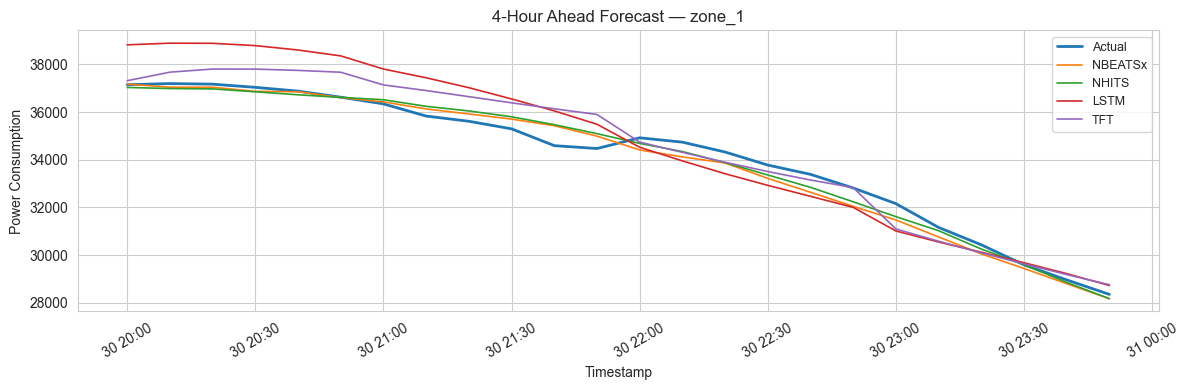

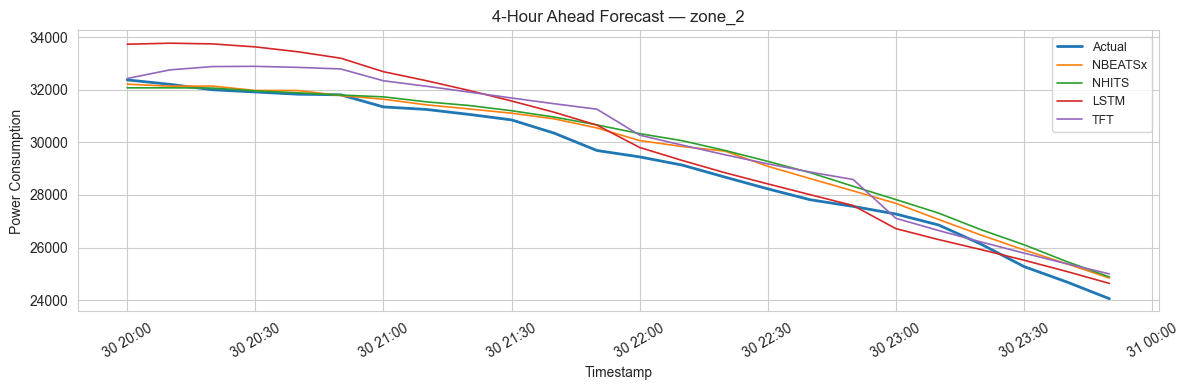

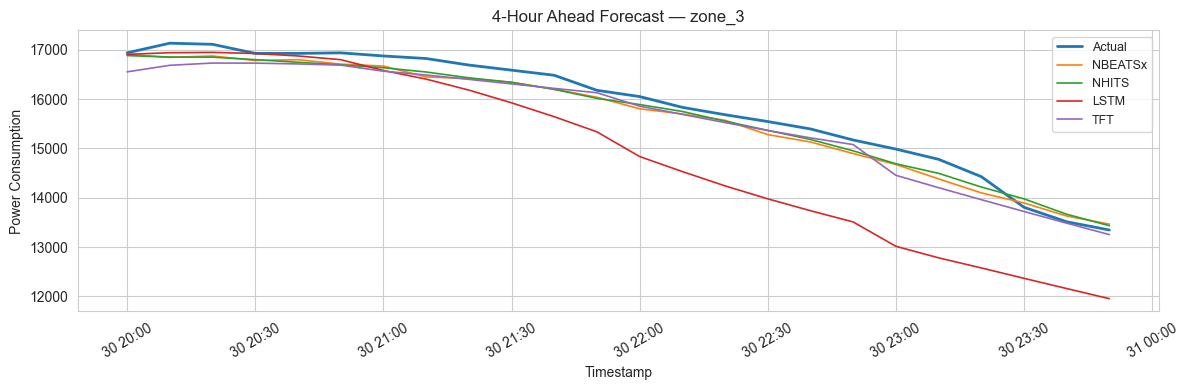

In [27]:
for uid, g in result.groupby("unique_id"):
    g = g.sort_values("ds")

    plt.figure(figsize=(12, 4))
    plt.plot(g["ds"], g["y"], label="Actual", linewidth=2)
    for col in model_cols:
        plt.plot(g["ds"], g[col], label=col, linewidth=1.2)

    plt.title(f"4-Hour Ahead Forecast — {uid}")
    plt.xlabel("Timestamp")
    plt.ylabel("Power Consumption")
    plt.xticks(rotation=30)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


## 6. Conclusions

| Finding | Detail |
|---------|--------|
| **Lasso baseline** | Achieves good R² due to strong autoregressive lag features; simple and interpretable |
| **Best neural model** | N-BEATSx and N-HiTS typically outperform LSTM and TFT for short-horizon forecasts |
| **Key features** | Lag-1 (previous 10 min) is the most predictive feature in the Lasso model |
| **Zone differences** | Zone 3 tends to show lower forecast errors; Zone 2 is more variable |

### Recommendations
- **Cross-validation**: Use time-series cross-validation (multiple forecast origin dates) for more robust model selection
- **Longer horizons**: Extend to 24-hour or weekly forecasts with additional lag features
- **Ensemble**: Combine Lasso with the best neural model for improved accuracy
- **Anomaly detection**: Flag periods with unusual consumption spikes
